In [2]:
!pip install -q torchsummary

In [16]:
import os, re, glob, math, random, warnings, time, gc
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
import torchvision.models as models
from PIL import Image, ImageFile

# Allow loading truncated/corrupted images instead of crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## Configuration

In [45]:
# ============ PATHS ============
IMAGE_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
ANNOT_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

assert os.path.isdir(IMAGE_DIR), f"IMAGE_DIR not found: {IMAGE_DIR}"
assert os.path.isdir(ANNOT_DIR), f"ANNOT_DIR not found: {ANNOT_DIR}"
print(f"Image dir: {IMAGE_DIR}")
print(f"Annot dir: {ANNOT_DIR}")

# ============ BIOLOGICAL PHASE ORDER ============
PHASE_ORDER = [
    'tPB2',  # 0  - second polar body extrusion
    'tPNa',  # 1  - pronuclei appearance
    'tPNf',  # 2  - pronuclei fading
    't2',    # 3  - 2-cell
    't3',    # 4  - 3-cell
    't4',    # 5  - 4-cell
    't5',    # 6  - 5-cell
    't6',    # 7  - 6-cell
    't7',    # 8  - 7-cell
    't8',    # 9  - 8-cell
    't9+',   # 10 - 9+ cells
    'tM',    # 11 - morula
    'tSB',   # 12 - start of blastulation
    'tB',    # 13 - blastocyst
    'tEB',   # 14 - expanded blastocyst
    'tHB',   # 15 - hatching blastocyst
]

# ============ LSTM / SEQUENCE ============
SEQ_LEN       = 10            # sliding window of 5 consecutive frames
HIDDEN_DIM    = 256          # LSTM hidden dimension
NUM_LSTM_LAYERS = 3          # stacked LSTM layers
LSTM_DROPOUT  = 0.3
FEAT_DIM      = 1280         # MobileNetV2 feature dimension

# ============ DATA ============
MAX_VIDEOS        = 400      # use a subset to keep training fast (set None for all)
SAMPLE_EVERY_N    = 1        # 1 = use every frame (no skipping)
MAX_FRAMES_VIDEO  = 2000
FEAT_BATCH_SIZE   = 64       # batch size for CNN feature extraction

# ============ TRAINING ============
BATCH_SIZE    = 64
NUM_WORKERS   = 4
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
LAMBDA_ORD    = 2.0          # ordinal distance penalty weight
EPOCHS        = 20
PATIENCE      = 5
SEED          = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Config loaded")

Image dir: /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
Annot dir: /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
Config loaded


## 🔍 Explore Dataset Structure

In [5]:
print("=== IMAGE DIR ===")
subdirs = sorted(os.listdir(IMAGE_DIR))
print(f"  {len(subdirs)} video folders")
if subdirs:
    first = subdirs[0]
    fpath = os.path.join(IMAGE_DIR, first)
    print(f"\n  Example: {first}/")
    children = sorted(os.listdir(fpath))[:10]
    for c in children:
        print(f"    {c}")

print("\n=== ANNOTATION DIR ===")
csvs = sorted(glob.glob(os.path.join(ANNOT_DIR, '*.csv')))
print(f"  {len(csvs)} CSV files")
if csvs:
    print(f"\n  Example: {Path(csvs[0]).name}")
    df_sample = pd.read_csv(csvs[0], header=None, names=['phase','start_frame','end_frame'])
    print(df_sample.head(10))

=== IMAGE DIR ===
  704 video folders

  Example: AA83-7/
    D2013.01.28_S0717_I132_WELL7_RUN1.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN10.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN100.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN101.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN102.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN103.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN104.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN105.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN106.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN107.jpeg

=== ANNOTATION DIR ===
  704 CSV files

  Example: AA83-7_phases.csv
  phase  start_frame  end_frame
0  tPB2            5         24
1  tPNa           25         88
2  tPNf           89         97
3    t2           98        171
4    t3          172        177
5    t4          178        191
6    t5          192        241
7    t6          242        256
8    t7          257        276
9    t8          277        286


## 1. Data Preparation
Read CSVs → extract frame numbers from RUN index → map to phase labels → build per-video frame lists

In [17]:
def extract_frame_number(filename):
    stem = Path(filename).stem
    match = re.search(r'RUN(\d+)', stem, re.IGNORECASE)
    if match:
        return int(match.group(1))
    numbers = re.findall(r'(\d+)', stem)
    return int(numbers[-1]) if numbers else None

def load_annotations(annot_dir):
    annotations = {}
    for csv_file in sorted(glob.glob(os.path.join(annot_dir, '*.csv'))):
        vname = Path(csv_file).stem
        for suffix in ['_phases', '_phase', '_annotations', '_annot', '_labels']:
            if vname.endswith(suffix):
                vname = vname[:-len(suffix)]
                break
        try:
            df = pd.read_csv(csv_file, header=None,
                             names=['phase', 'start_frame', 'end_frame'])
            df['phase'] = df['phase'].astype(str).str.strip()
            df['start_frame'] = pd.to_numeric(df['start_frame'], errors='coerce')
            df['end_frame']   = pd.to_numeric(df['end_frame'], errors='coerce')
            df = df.dropna(subset=['start_frame', 'end_frame', 'phase'])
            df['start_frame'] = df['start_frame'].astype(int)
            df['end_frame']   = df['end_frame'].astype(int)
            if len(df) > 0:
                annotations[vname] = df
        except Exception as e:
            print(f"  WARN: {csv_file}: {e}")
    print(f"Loaded annotations for {len(annotations)} videos")
    keys = sorted(annotations.keys())[:5]
    print(f"  Sample keys: {keys}")
    return annotations

def get_frame_label(fnum, annot_df):
    for _, row in annot_df.iterrows():
        if row['start_frame'] <= fnum <= row['end_frame']:
            return str(row['phase']).strip()
    return None

def match_annotation(vdir, annotations):
    if vdir in annotations:
        return annotations[vdir]
    vdir_l = vdir.lower()
    for key in annotations:
        if key.lower() == vdir_l:
            return annotations[key]
    for key in annotations:
        if key.lower() in vdir_l or vdir_l in key.lower():
            return annotations[key]
    return None

def build_dataset(image_dir, annotations,
                  sample_every_n=1, max_per_video=2000, max_videos=None):
    """Build a flat list of (img_path, label, video_name, frame_number) tuples."""
    dataset = []
    skip_annot, skip_label = 0, 0
    video_dirs = sorted([d for d in os.listdir(image_dir)
                         if os.path.isdir(os.path.join(image_dir, d))])
    # Optionally limit number of videos
    if max_videos and len(video_dirs) > max_videos:
        random.seed(SEED)
        video_dirs = sorted(random.sample(video_dirs, max_videos))
    print(f"Processing {len(video_dirs)} video directories")
    for vdir in video_dirs:
        vpath = os.path.join(image_dir, vdir)
        annot_df = match_annotation(vdir, annotations)
        if annot_df is None:
            skip_annot += 1
            continue
        img_files = sorted(
            glob.glob(os.path.join(vpath, '*.jpg')) +
            glob.glob(os.path.join(vpath, '*.jpeg')) +
            glob.glob(os.path.join(vpath, '*.png')))
        if not img_files:
            img_files = sorted(
                glob.glob(os.path.join(vpath, '**', '*.jpg'), recursive=True) +
                glob.glob(os.path.join(vpath, '**', '*.jpeg'), recursive=True) +
                glob.glob(os.path.join(vpath, '**', '*.png'), recursive=True))
        frame_data = []
        for img in img_files:
            fnum = extract_frame_number(os.path.basename(img))
            if fnum is not None:
                frame_data.append((img, fnum))
        frame_data.sort(key=lambda x: x[1])
        frame_data = frame_data[::sample_every_n]
        if len(frame_data) > max_per_video:
            idx = np.linspace(0, len(frame_data)-1, max_per_video, dtype=int)
            frame_data = [frame_data[i] for i in idx]
        for img_path, fnum in frame_data:
            label = get_frame_label(fnum, annot_df)
            if label is not None:
                dataset.append((img_path, label, vdir, fnum))
            else:
                skip_label += 1
    print(f"\nDataset: {len(dataset)} samples from {len(video_dirs) - skip_annot} videos")
    print(f"  Skipped {skip_annot} videos (no annotation)")
    print(f"  Skipped {skip_label} frames (no label)")
    return dataset

# ---- Run ----
annotations = load_annotations(ANNOT_DIR)
dataset_raw = build_dataset(IMAGE_DIR, annotations,
                            sample_every_n=SAMPLE_EVERY_N,
                            max_per_video=MAX_FRAMES_VIDEO,
                            max_videos=MAX_VIDEOS)

Loaded annotations for 704 videos
  Sample keys: ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1', 'AC264-1']
Processing 400 video directories

Dataset: 169630 samples from 400 videos
  Skipped 0 videos (no annotation)
  Skipped 25603 frames (no label)


Classes (16): ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']

Class distribution:
            t2:  16489
            t3:   3081
            t4:  16367
            t5:   4877
            t6:   4504
            t7:   6566
            t8:  18410
           t9+:  29912
            tB:   6116
           tEB:  11002
           tHB:     28
            tM:   9714
          tPB2:   4838
          tPNa:  24389
          tPNf:   3825
           tSB:   9512


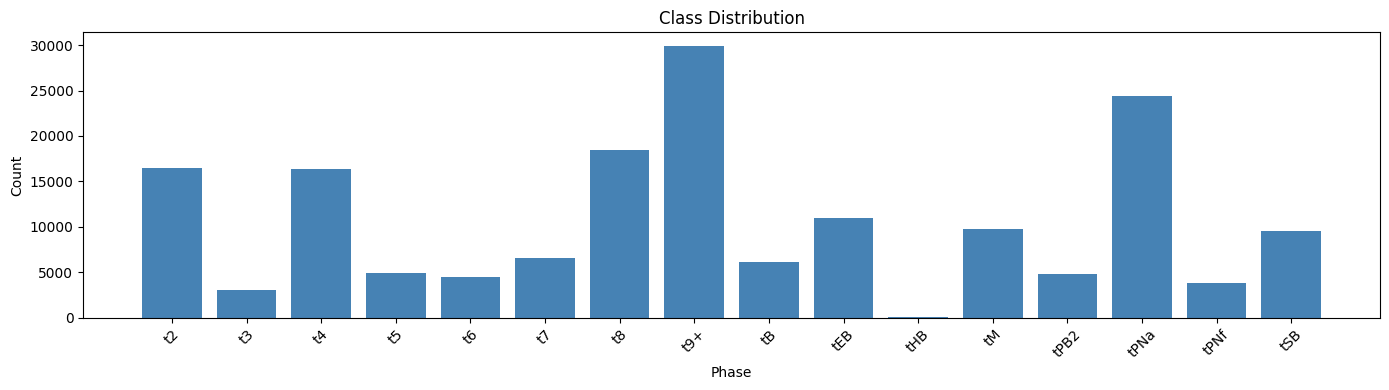


Ordinal positions (per class index):
      t2 -> rank 3
      t3 -> rank 4
      t4 -> rank 5
      t5 -> rank 6
      t6 -> rank 7
      t7 -> rank 8
      t8 -> rank 9
     t9+ -> rank 10
      tB -> rank 13
     tEB -> rank 14
     tHB -> rank 15
      tM -> rank 11
    tPB2 -> rank 0
    tPNa -> rank 1
    tPNf -> rank 2
     tSB -> rank 12

Class weights (effective-number): [ 0.312  0.327  0.312  0.314  0.315  0.312  0.312  0.312  0.313  0.312
 11.29   0.312  0.314  0.312  0.319  0.312]


In [18]:
# ---- Labels, class distribution, ordinal mapping, class weights ----
all_labels = sorted(set(row[1] for row in dataset_raw))
label2idx = {lbl: i for i, lbl in enumerate(all_labels)}
idx2label = {i: lbl for lbl, i in label2idx.items()}
NUM_CLASSES = len(label2idx)
print(f"Classes ({NUM_CLASSES}): {all_labels}\n")

label_counts = Counter(row[1] for row in dataset_raw)
print("Class distribution:")
for lbl in all_labels:
    print(f"  {lbl:>12s}: {label_counts[lbl]:>6d}")

fig, ax = plt.subplots(figsize=(14, 4))
counts_arr = np.array([label_counts[l] for l in all_labels], dtype=float)
ax.bar(all_labels, counts_arr, color='steelblue')
ax.set_xlabel('Phase'); ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ---- Ordinal positions (biological order -> class-index mapping) ----
ordinal_positions = torch.zeros(NUM_CLASSES)
for rank, phase in enumerate(PHASE_ORDER):
    if phase in label2idx:
        ordinal_positions[label2idx[phase]] = float(rank)
ordinal_positions = ordinal_positions.to(device)
print(f"\nOrdinal positions (per class index):")
for i in range(NUM_CLASSES):
    print(f"  {idx2label[i]:>6s} -> rank {int(ordinal_positions[i].item())}")

# ---- Class weights via Effective Number of Samples ----
# (Class-Balanced Loss, Cui et al. 2019)
beta = 0.999
effective_num = 1.0 - np.power(beta, counts_arr)
per_cls_weights = (1.0 - beta) / effective_num # higher for small classs and vice-versa
per_cls_weights = per_cls_weights / per_cls_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(per_cls_weights, dtype=torch.float32).to(device)
print(f"\nClass weights (effective-number): {class_weights.cpu().numpy().round(3)}")

## 2. CNN Feature Extraction (One-Time)

We use a **frozen MobileNetV2** (pre-trained on ImageNet) as a feature extractor.  
Each 224×224 frame is mapped to a **1280-dimensional feature vector**.  

This is a one-time cost — features are cached in memory and reused across all LSTM training epochs,
making LSTM training extremely fast.

## 3. Sequence Building & Video-Wise Split

**Sliding window**: For each video, we create overlapping sequences of `SEQ_LEN=5` consecutive frames.  
The **target label** is the phase of the **last frame** in each sequence.  
Split is done **by video** to prevent data leakage.

In [19]:
# ---- Organize frames by video ----
video_frames = defaultdict(list)
for img_path, label, vdir, fnum in dataset_raw:
    video_frames[vdir].append((img_path, fnum, label))

# Sort frames within each video by frame number
for vdir in video_frames:
    video_frames[vdir].sort(key=lambda x: x[1])

print(f"Videos with features: {len(video_frames)}")
print(f"Frames per video (sample): ", end='')
sample_vids = list(video_frames.keys())[:5]
for v in sample_vids:
    print(f"{v}={len(video_frames[v])}, ", end='')
print()

# ---- Build sliding-window sequences per video ----
def build_sequences(video_frames_dict, seq_len):
    """Build sliding window sequences from per-video frame lists.
    
    Returns: list of (video_name, [path1, ..., pathN], target_label)
    Target label = label of the LAST frame in the window.
    """
    sequences = []
    short_videos = 0
    for vname, frames in video_frames_dict.items():
        if len(frames) < seq_len:
            short_videos += 1
            continue
        stride = seq_len//2
        for i in range(0, len(frames) - seq_len + 1, stride):
            window = frames[i:i+seq_len]
            paths = [f[0] for f in window]
            target = window[-1][2]  # label of last frame
            sequences.append((vname, paths, target))
    print(f"Built {len(sequences):,} sequences (seq_len={seq_len})")
    if short_videos:
        print(f"  Skipped {short_videos} videos with < {seq_len} frames")
    return sequences

all_sequences = build_sequences(video_frames, SEQ_LEN)

# ---- Video-wise train/val/test split ----
def video_wise_split_sequences(sequences, val_ratio=0.15, test_ratio=0.15):
    """Split sequences by video to prevent data leakage."""
    # Group sequences by video
    video_seqs = defaultdict(list)
    for seq in sequences:
        video_seqs[seq[0]].append(seq)
    
    video_names = sorted(video_seqs.keys())
    random.seed(SEED)
    random.shuffle(video_names)
    
    n = len(video_names)
    n_test = max(1, int(n * test_ratio))
    n_val  = max(1, int(n * val_ratio))
    
    test_vids  = video_names[:n_test]
    val_vids   = video_names[n_test:n_test+n_val]
    train_vids = video_names[n_test+n_val:]
    
    train_seqs = [s for v in train_vids for s in video_seqs[v]]
    val_seqs   = [s for v in val_vids   for s in video_seqs[v]]
    test_seqs  = [s for v in test_vids  for s in video_seqs[v]]
    
    print(f"\nSplit (by video):")
    print(f"  Train: {len(train_seqs):,} seqs ({len(train_vids)} videos)")
    print(f"  Val:   {len(val_seqs):,} seqs ({len(val_vids)} videos)")
    print(f"  Test:  {len(test_seqs):,} seqs ({len(test_vids)} videos)")
    return train_seqs, val_seqs, test_seqs

train_seqs, val_seqs, test_seqs = video_wise_split_sequences(all_sequences)

Videos with features: 400
Frames per video (sample): AA83-7=281, AAL839-6=544, AB91-1=387, AC264-1=223, AG274-2=555, 
Built 33,359 sequences (seq_len=10)

Split (by video):
  Train: 23,030 seqs (280 videos)
  Val:   5,232 seqs (60 videos)
  Test:  5,097 seqs (60 videos)


## 4. Sequence Dataset & DataLoaders

Each sample is a **(sequence_of_features, label)** pair.  
Features are pre-extracted tensors of shape `(seq_len, 1280)`.  
Training uses **WeightedRandomSampler** to oversample rare phases.

In [46]:
class SequenceDataset(Dataset):
    def __init__(self, sequences, transform, label2idx):
        self.sequences = sequences
        self.transform = transform
        self.label2idx = label2idx

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        _, paths, label = self.sequences[idx]

        imgs = []
        for p in paths:
            img = Image.open(p).convert('RGB')
            img = self.transform(img)
            imgs.append(img)

        imgs = torch.stack(imgs)  # (T, C, H, W)

        return imgs, self.label2idx[label]

def make_sequence_loaders(train_seqs, val_seqs, test_seqs,
                          transform, label2idx, bs=128):

    train_ds = SequenceDataset(train_seqs, transform, label2idx)
    val_ds   = SequenceDataset(val_seqs,   transform, label2idx)
    test_ds  = SequenceDataset(test_seqs,  transform, label2idx)

    # ---- Weighted sampler ----
    train_lbl_counts = Counter(s[2] for s in train_seqs)
    sample_w = [1.0 / train_lbl_counts[s[2]] for s in train_seqs]

    sampler = WeightedRandomSampler(
        sample_w,
        num_samples=len(train_seqs),
        replacement=True
    )

    kw = dict(num_workers=NUM_WORKERS, pin_memory=True)

    train_loader = DataLoader(
        train_ds,
        batch_size=bs,
        sampler=sampler,   # no shuffle here
        **kw
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=bs,
        shuffle=False,
        **kw
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=bs,
        shuffle=False,
        **kw
    )

    print(f"Loaders ready (bs={bs}):")
    print(f"  Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

    return train_loader, val_loader, test_loader
BATCH_SIZE = 64
print("Bathc Size:", BATCH_SIZE)
train_loader, val_loader, test_loader = make_sequence_loaders(
    train_seqs, val_seqs, test_seqs, feat_transform, label2idx, bs=BATCH_SIZE)

Bathc Size: 64
Loaders ready (bs=64):
  Train: 360 batches | Val: 82 | Test: 80


In [34]:

images, labels = next(iter(train_loader))
print(type(images), images.shape)

<class 'torch.Tensor'> torch.Size([128, 10, 3, 224, 224])


##  5. LSTM Model Architecture

```
Input: (batch, seq_len=5, feat_dim=1280)
  │
  └──→ LSTM (2 layers, hidden=256, dropout=0.3)
        │
        └──→ last time-step hidden state: (batch, 256)
              │
              └──→ Dropout(0.3) → Linear(256, 16) → logits
```

The LSTM reads the sequence of CNN feature vectors and learns temporal patterns.  
We use the **last time-step's output** to classify the current developmental phase.

In [47]:
class EmbryoNet(nn.Module):
    def __init__(self, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()

        # ---- Backbone ----
        self.backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Identity()

        # Freeze everything
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Unfreeze last layers
        for p in self.backbone.features[17:].parameters():
            p.requires_grad = True

        # ---- LSTM ----
        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, C, H, W)

        B, T, C, H, W = x.shape

        # Flatten time dimension
        x = x.view(B * T, C, H, W)

        # CNN forward (gradients ON)
        feats = self.backbone(x)   # (B*T, 1280)

        # Reshape back to sequence
        feats = feats.view(B, T, -1)  # (B, T, 1280)

        # LSTM
        lstm_out, _ = self.lstm(feats)

        last_output = lstm_out[:, -1, :]
        logits = self.classifier(last_output)

        return logits

# ---- Build model ----
model = EmbryoNet(
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LSTM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=LSTM_DROPOUT
).to(device)

print(model)

# ---- Parameter stats ----
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ---- Detailed parameter breakdown ----
print("\nParameter breakdown:")
for name, param in model.named_parameters():
    status = "Trainable" if param.requires_grad else "Frozen"
    print(f"{name:>50s}  {str(list(param.shape)):>20s}  {param.numel():>12,}  {status}")

EmbryoNet(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1,

##  6. Custom Loss Function

### Total Loss = L_WCE + λ · L_ord

**L_WCE** — Weighted Cross-Entropy Loss (handles class imbalance):  
$$\mathcal{L}_{WCE} = -\sum_{c=1}^{C} w_c \cdot y_c \cdot \log(\hat{y}_c)$$

**L_ord** — Ordinal Phase Distance Loss:  
$$\mathcal{L}_{ord} = \frac{1}{B} \sum_{b=1}^{B} \left(\frac{\hat{r}_b - r_{y_b}}{C - 1}\right)^2$$

where:
- $\hat{r}_b = \sum_{c=1}^{C} p_{bc} \cdot o_c$ — expected developmental rank from softmax probabilities
- $r_{y_b} = o_{y_b}$ — true developmental rank of ground-truth class
- $o_c$ — ordinal position of class $c$ in the biological timeline (0 = tPB2 … 15 = tHB)

In [48]:
class OrdinalDistanceLoss(nn.Module):
    """Penalizes predictions based on developmental distance between phases.
    
    L_ord = mean( ((sum(p_c * o_c) - o_true) / (C-1))^2 )
    """
    def __init__(self, ordinal_positions):
        super().__init__()
        self.register_buffer('ord_pos', ordinal_positions.float())
        self.C = len(ordinal_positions)

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)                          # (B, C)
        pred_rank = (probs * self.ord_pos.unsqueeze(0)).sum(1)     # (B,)
        true_rank = self.ord_pos[targets]                          # (B,)
        loss = ((pred_rank - true_rank) / (self.C - 1)) ** 2
        return loss.mean()


class CombinedLoss(nn.Module):
    """L_total = L_WCE + lambda_ord * L_ord"""
    def __init__(self, class_weights, ordinal_positions, lambda_ord=2.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.ord_loss = OrdinalDistanceLoss(ordinal_positions)
        self.lambda_ord = lambda_ord

    def forward(self, logits, targets):
        l_ce  = self.ce(logits, targets)
        l_ord = self.ord_loss(logits, targets)
        total = l_ce + self.lambda_ord * l_ord
        return  total, l_ce, l_ord

criterion = CombinedLoss(class_weights, ordinal_positions, lambda_ord=LAMBDA_ORD)
print(f"Custom loss ready: L_WCE + {LAMBDA_ORD} * L_ord")

Custom loss ready: L_WCE + 2.0 * L_ord


## 7. Training with Early Stopping

In [50]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_ce, total_ord = 0, 0, 0
    correct, total = 0, 0

    for images, labels in loader:
        images = images.to(device)   # (B, T, C, H, W)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)   # CNN + LSTM forward

        loss, ce_v, ord_v = criterion(logits, labels)
        loss.backward()

        # Gradient clipping (still useful for LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_ce   += ce_v * bs
        total_ord  += ord_v * bs

        _, preds = logits.max(1)
        correct += preds.eq(labels).sum().item()
        total   += bs

    return total_loss/total, total_ce/total, total_ord/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)   # (B, T, C, H, W)
        labels = labels.to(device)

        logits = model(images)

        loss, _, _ = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)

        _, preds = logits.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss/total, correct/total, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, patience):

    best_val_loss = float('inf')
    wait = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'ce': [], 'ord': []
    }

    best_state = None

    for epoch in range(num_epochs):
        t0 = time.time()

        tr_loss, tr_ce, tr_ord, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer)

        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)

        dt = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['ce'].append(tr_ce)
        history['ord'].append(tr_ord)

        print(f"Ep {epoch+1:2d}/{num_epochs} | "
              f"Loss: {tr_loss:.4f} (CE:{tr_ce:.4f} Ord:{tr_ord:.4f}) "
              f"Acc: {tr_acc:.4f} | Val: {vl_loss:.4f}/{vl_acc:.4f} | {dt:.1f}s")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            wait = 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model, history
print("train functionso are rdy!")

train functionso are rdy!


In [61]:
print(f"{'='*70}")
print(f"  TRAINING CNN + LSTM")
print(f"  seq_len={SEQ_LEN}, hidden={HIDDEN_DIM}, layers={NUM_LSTM_LAYERS}")
print(f"  lr={LR}, epochs={EPOCHS}, patience={PATIENCE}")
print(f"{'='*70}")

optimizer = optim.Adam([
    {"params": model.backbone.features[15:].parameters(), "lr": 1e-5},
    {"params": model.lstm.parameters(), "lr": LR},
    {"params": model.classifier.parameters(), "lr": LR},
], weight_decay=WEIGHT_DECAY)

EPOCHS = 10
model, history = train_model(
    model, train_loader, val_loader, criterion,
    optimizer, EPOCHS, PATIENCE
)

print("\nTraining complete!")

  TRAINING CNN + LSTM
  seq_len=10, hidden=256, layers=3
  lr=0.001, epochs=10, patience=5
Ep  1/10 | Loss: 0.5742 (CE:0.5533 Ord:0.0105) Acc: 0.3590 | Val: 1.6258/0.4230 | 770.4s
Ep  2/10 | Loss: 0.5052 (CE:0.4908 Ord:0.0072) Acc: 0.4189 | Val: 1.7317/0.3016 | 706.2s
Ep  3/10 | Loss: 0.4893 (CE:0.4761 Ord:0.0066) Acc: 0.4452 | Val: 1.6290/0.3211 | 700.8s
Ep  4/10 | Loss: 0.4889 (CE:0.4776 Ord:0.0056) Acc: 0.4792 | Val: 1.6910/0.3232 | 694.7s
Ep  5/10 | Loss: 0.4521 (CE:0.4430 Ord:0.0045) Acc: 0.5219 | Val: 1.6513/0.4228 | 698.3s
Ep  6/10 | Loss: 0.4083 (CE:0.3999 Ord:0.0042) Acc: 0.5637 | Val: 1.5749/0.4906 | 693.2s
Ep  7/10 | Loss: 0.3716 (CE:0.3638 Ord:0.0039) Acc: 0.6119 | Val: 1.7731/0.4404 | 695.7s
Ep  8/10 | Loss: 0.3444 (CE:0.3375 Ord:0.0034) Acc: 0.6385 | Val: 1.6731/0.4421 | 694.2s
Ep  9/10 | Loss: 0.3277 (CE:0.3211 Ord:0.0033) Acc: 0.6535 | Val: 1.6585/0.4467 | 696.3s
Ep 10/10 | Loss: 0.3185 (CE:0.3125 Ord:0.0030) Acc: 0.6769 | Val: 1.7248/0.4379 | 713.8s

Training complete!

In [63]:
# gc.collect()
# torch.cuda.empty_cache()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

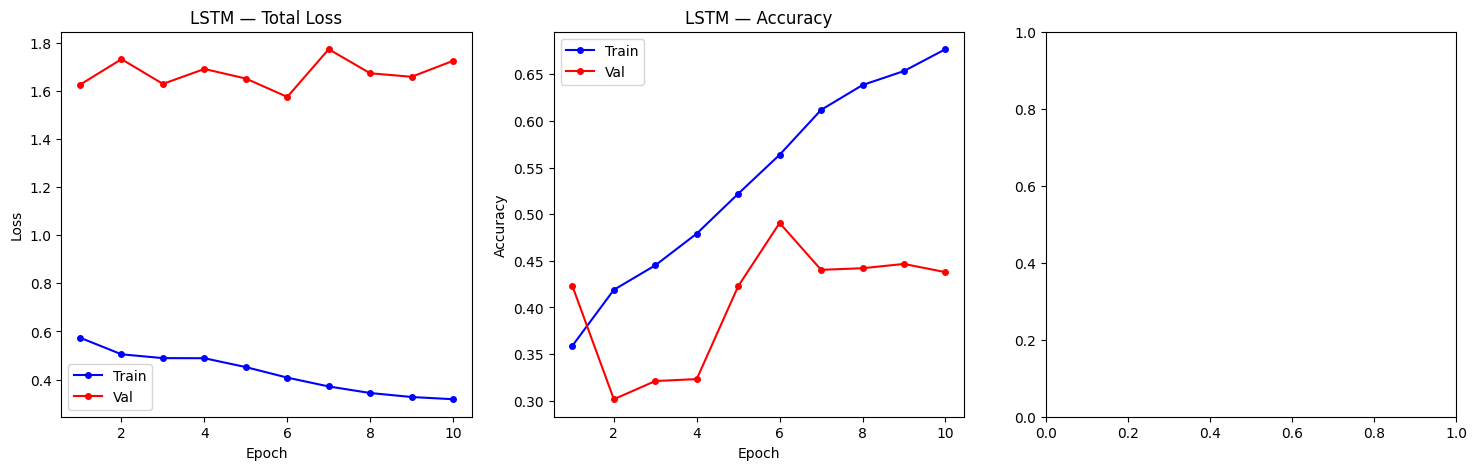

In [64]:
# ---- Training History Plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(ep, history['val_loss'], 'r-o', label='Val', markersize=4)
axes[0].set_title('LSTM — Total Loss'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(ep, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[1].plot(ep, history['val_acc'], 'r-o', label='Val', markersize=4)
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(ep, history['ce'], 'g-o', label='L_WCE', markersize=4)
axes[2].plot(ep, history['ord'], 'm-o', label='L_ord', markersize=4)
axes[2].set_title('LSTM — Loss Components'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')

plt.tight_layout(); plt.show()

## 8. Evaluation & Results

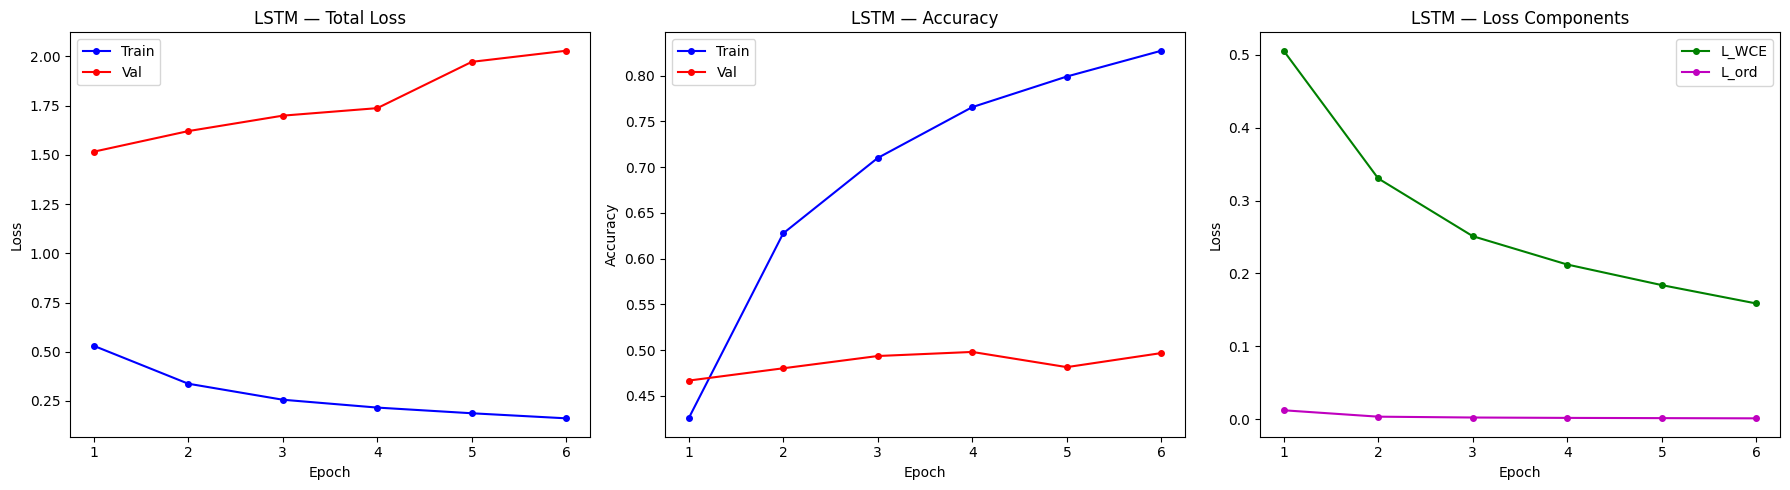

In [32]:
# ---- Training History Plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(ep, history['val_loss'], 'r-o', label='Val', markersize=4)
axes[0].set_title('LSTM — Total Loss'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(ep, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[1].plot(ep, history['val_acc'], 'r-o', label='Val', markersize=4)
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(ep, history['ce'], 'g-o', label='L_WCE', markersize=4)
axes[2].plot(ep, history['ord'], 'm-o', label='L_ord', markersize=4)
axes[2].set_title('LSTM — Loss Components'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')

plt.tight_layout(); plt.show()

In [33]:
# ---- Test Set Evaluation ----
_, test_acc, preds, labels = evaluate(model, test_loader, criterion)

print(f"\n{'='*60}")
print(f"  LSTM — Test Accuracy: {test_acc*100:.2f}%")
print(f"{'='*60}")

target_names = [idx2label[i] for i in range(NUM_CLASSES)]
print(classification_report(labels, preds, labels=list(range(NUM_CLASSES)), target_names=target_names, zero_division=0))



  LSTM — Test Accuracy: 44.42%
              precision    recall  f1-score   support

          t2       0.56      0.65      0.60      2497
          t3       0.12      0.16      0.14       468
          t4       0.48      0.34      0.40      2306
          t5       0.09      0.12      0.10       689
          t6       0.07      0.13      0.09       719
          t7       0.05      0.04      0.05       963
          t8       0.42      0.29      0.35      2657
         t9+       0.61      0.50      0.55      4601
          tB       0.22      0.40      0.28       980
         tEB       0.72      0.57      0.64      2178
         tHB       0.00      0.00      0.00         2
          tM       0.32      0.47      0.39      1508
        tPB2       0.21      0.60      0.31       285
        tPNa       0.78      0.59      0.67      3370
        tPNf       0.45      0.63      0.52       526
         tSB       0.37      0.40      0.38      1628

    accuracy                           0.44     

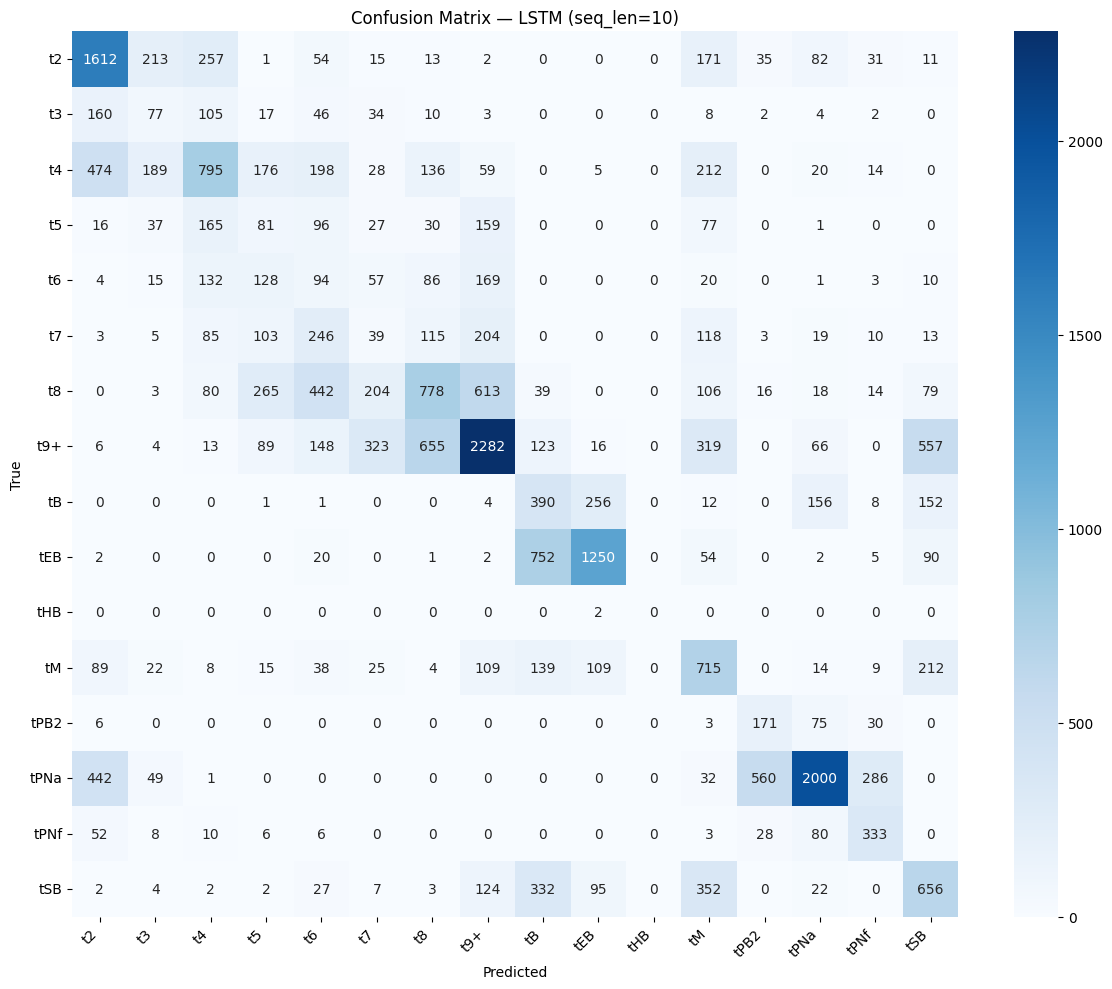

In [34]:
# ---- Confusion Matrix ----
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — LSTM (seq_len={SEQ_LEN})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 9. Final Summary

In [35]:
print(f"{'='*60}")
print(f"  LSTM CLASSIFICATION SUMMARY")
print(f"{'='*60}")
print(f"")
print(f"  Architecture:")
print(f"    Feature Extractor:  MobileNetV2 (frozen, ImageNet)")
print(f"    Feature Dim:        {FEAT_DIM}")
print(f"    LSTM Hidden:        {HIDDEN_DIM}")
print(f"    LSTM Layers:        {NUM_LSTM_LAYERS}")
print(f"    Sequence Length:    {SEQ_LEN}")
print(f"    Dropout:            {LSTM_DROPOUT}")
print(f"")
print(f"  Data:")
print(f"    Videos Used:        {len(video_frames)}")
print(f"    Total Frames:       {len(features):,}")
print(f"    Total Sequences:    {len(all_sequences):,}")
print(f"    Train / Val / Test: {len(train_seqs):,} / {len(val_seqs):,} / {len(test_seqs):,}")
print(f"    Classes:            {NUM_CLASSES}")
print(f"")
print(f"  Training:")
print(f"    Loss:       L_WCE + {LAMBDA_ORD} * L_ord")
print(f"    Optimizer:  Adam (lr={LR}, wd={WEIGHT_DECAY})")
print(f"    Epochs:     {len(history['train_loss'])} / {EPOCHS}")
print(f"    Patience:   {PATIENCE}")
print(f"")
print(f"  Results:")
print(f"    Test Accuracy:  {test_acc*100:.2f}%")
print(f"")
print(f"  Parameters:")
print(f"    LSTM + Classifier: {trainable_params:,} (all trainable)")
print(f"    CNN Backbone:      ~3.5M (frozen, not counted)")
print(f"{'='*60}")

  LSTM CLASSIFICATION SUMMARY

  Architecture:
    Feature Extractor:  MobileNetV2 (frozen, ImageNet)
    Feature Dim:        1280
    LSTM Hidden:        256
    LSTM Layers:        3
    Sequence Length:    10
    Dropout:            0.3

  Data:
    Videos Used:        400
    Total Frames:       169,630
    Total Sequences:    166,030
    Train / Val / Test: 114,613 / 26,040 / 25,377
    Classes:            16

  Training:
    Loss:       L_WCE + 2.0 * L_ord
    Optimizer:  Adam (lr=0.001, wd=1e-05)
    Epochs:     6 / 20
    Patience:   5

  Results:
    Test Accuracy:  44.42%

  Parameters:
    LSTM + Classifier: 2,631,696 (all trainable)
    CNN Backbone:      ~3.5M (frozen, not counted)
